# ClusterMind Chaos Arena — Training Notebook (TRL / Unsloth-compatible)

**This notebook is judge-runnable end-to-end on a free Colab T4.**

Two paths exist; the script picks automatically based on what's installed:

| Path | When | What runs |
|---|---|---|
| **LLM / LoRA (preferred)** | `transformers + peft` available (Colab default) | Qwen2.5-0.5B-Instruct base, **frozen weights**, LoRA r=8, SFT cross-entropy → online RL on live env |
| **Policy-net plumbing (fallback)** | Bare torch only (laptop CPU) | Tiny MLP over engineered features, BC + REINFORCE — proves the loop with no GPU |

> **Disclosure (PRD §26):** We freeze the base model and update only LoRA adapter weights during SFT and GRPO/PPO/REINFORCE training.

Estimated runtime: ~12 min quick mode, ~40 min `--full` on a T4.

## 1 — Install dependencies

In [1]:
!pip install -q openenv-core pydantic numpy matplotlib pandas plotly networkx PyYAML
!pip install -q transformers accelerate peft trl sentencepiece einops datasets bitsandbytes
!pip install -q gradio
# wandb is optional; uncomment to use:
# !pip install -q wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.6/174.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.6/728.6 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.3/152.3 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2 — Clone the repo

In [2]:
import os, sys
# Repo is cloned in the next cell — this cell is kept for compatibility.
REPO = '/kaggle/working/clustermind-chaos-arena' if os.path.isdir('/kaggle/working') else '/content/clustermind-chaos-arena'
print('REPO =', REPO)

Cloning into '/content/clustermind-chaos-arena'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 60 (delta 2), reused 58 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 629.52 KiB | 14.31 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/clustermind-chaos-arena
repo ready at /content/clustermind-chaos-arena


## 3 — Imports

In [3]:
import os, sys
# Auto-detect Kaggle vs Colab
REPO = '/kaggle/working/clustermind-chaos-arena' if os.path.isdir('/kaggle/working') else '/content/clustermind-chaos-arena'
REPO_URL = 'https://github.com/Kabeer-Scaler/META_RL_HACKATHON_CLUSTERMIND.git'
if os.path.isdir(REPO) and not os.path.isdir(os.path.join(REPO, 'clustermind')):
    !rm -rf $REPO
if not os.path.isdir(REPO):
    !git clone --depth=1 $REPO_URL $REPO
else:
    !git -C $REPO pull --ff-only
%cd $REPO
sys.path.insert(0, REPO)
assert os.path.isdir(os.path.join(REPO, 'clustermind')), 'clone failed — check internet access'
print('repo ready at', REPO)

/content/clustermind-chaos-arena
repo ready


In [4]:
import sys
import os
import importlib

REPO = '/kaggle/working/clustermind-chaos-arena' if os.path.isdir('/kaggle/working') else '/content/clustermind-chaos-arena'

# Force refresh of sys.path
if REPO not in sys.path:
    sys.path.insert(0, REPO)

# Invalidate caches to force Python to see new files
importlib.invalidate_caches()

try:
    from clustermind import ClusterMindChaosEnv, ClusterMindEnv
    from clustermind.baselines import ALL_BASELINES, RandomAgent, GreedyThroughputAgent, ThermalAwareHeuristicAgent
    from clustermind.agents import LLMJsonAgent, TransformersBackend
    from clustermind.scenarios import SCENARIO_NAMES
    print('Successfully imported clustermind!')
    print('Baselines:', list(ALL_BASELINES.keys()))
    print('Scenarios:', SCENARIO_NAMES)
except ImportError as e:
    print(f'Import still failed: {e}')
    print(f'Checking {REPO}/clustermind contents: {os.listdir(os.path.join(REPO, "clustermind")) if os.path.exists(os.path.join(REPO, "clustermind")) else "Directory not found"}')

Successfully imported clustermind!
Baselines: ['RandomAgent', 'GreedyThroughputAgent', 'ConservativeAutoscalerAgent', 'ThermalAwareHeuristicAgent', 'BackfillAgent']
Scenarios: ['demand_spike', 'cooling_failure', 'hidden_degradation', 'cascading_failure', 'energy_squeeze', 'vip_job_arrival', 'triple_crisis', 'chaos_arena']


## 4 — Smoke tests (17 checks must pass)

In [5]:
!python scripts/run_smoke_tests.py

[PASS] env.reset returns valid observation
[PASS] env.step returns quad
[PASS] env.state returns hidden state
[PASS] episode terminates at max_steps
[PASS] seeded determinism (job IDs)
[PASS] all 8 scenarios reset+step
[PASS] all 5 baselines run an episode
[PASS] reward clipped to [-1, 1]
[PASS] invalid action does not crash
[PASS] thermal dynamics run
[PASS] cooling action accepted
[PASS] guardrail evaluation runs
[PASS] flight recorder captures steps
[PASS] failure chain explanation produced
[PASS] chaos respects per-episode budget
[PASS] chaos disabled at low levels
[PASS] observation is JSON serialisable

Smoke tests: 17/17 passed


## 5 — Baseline quick sweep
Runs all 5 heuristics on all 8 scenarios at curriculum levels 3/4/5. Result is the comparison ground truth that the trained agent has to beat.

In [6]:
!python scripts/run_baselines.py --episodes 5 --levels 3 4 5 --output results/baseline_metrics.json

RandomAgent                      reward=  7.56 crit= 13.2% outage=2.85 cascade=1.04 gv_rate=0.37 inv_rate=0.00
GreedyThroughputAgent            reward=  9.76 crit= 93.0% outage=3.40 cascade=1.35 gv_rate=0.16 inv_rate=0.00
ConservativeAutoscalerAgent      reward=  8.56 crit= 93.3% outage=3.64 cascade=1.46 gv_rate=0.16 inv_rate=0.00
ThermalAwareHeuristicAgent       reward= 10.03 crit= 89.2% outage=3.54 cascade=1.43 gv_rate=0.15 inv_rate=0.00
BackfillAgent                    reward=  9.98 crit= 90.6% outage=3.46 cascade=1.35 gv_rate=0.16 inv_rate=0.00

Saved results/baseline_metrics.json


In [7]:
import json
with open('results/baseline_metrics.json') as f:
    payload = json.load(f)
print(f"{'agent':32s} {'reward':>7s} {'crit%':>6s} {'outage':>7s} {'cascade':>8s} {'gv_rate':>8s}")
print('-' * 75)
for name, blob in payload['agents'].items():
    s = blob['summary']
    print(f"{name:32s} {s['avg_reward']:7.2f} {s['critical_completion_rate']*100:5.1f}%"
          f" {s['avg_outage_count']:7.2f} {s['avg_cascade_count']:8.2f} {s['avg_guardrail_violation_rate']:8.2f}")

agent                             reward  crit%  outage  cascade  gv_rate
---------------------------------------------------------------------------
RandomAgent                         7.56  13.2%    2.85     1.04     0.37
GreedyThroughputAgent               9.76  93.0%    3.40     1.35     0.16
ConservativeAutoscalerAgent         8.56  93.3%    3.64     1.46     0.16
ThermalAwareHeuristicAgent         10.03  89.2%    3.54     1.43     0.15
BackfillAgent                       9.98  90.6%    3.46     1.35     0.16


## 6 — Collect heuristic rollouts (SFT seed data)
Filtered for: valid action AND no guardrail violation AND positive reward (PRD §26.1).

In [8]:
from scripts.train_trl import collect_heuristic_rollouts
rollouts = collect_heuristic_rollouts(n_episodes=16, seed_base=7000)
print(f'Collected {len(rollouts)} filtered transitions for SFT')
by_action = {}
for r in rollouts:
    by_action[r.abstract_action.value] = by_action.get(r.abstract_action.value, 0) + 1
print('action distribution:', by_action)

Collected 278 filtered transitions for SFT
action distribution: {'ALLOCATE_JOB': 64, 'NO_OP': 196, 'DELAY_JOB': 14, 'INCREASE_COOLING': 4}


## 7 — Train: frozen base + LoRA, SFT → GRPO/PPO/REINFORCE

The script picks the strongest RL algorithm available:
- `--rl-algo grpo` — episode-level group-relative advantage with K=2 trajectories per seed
- `--rl-algo ppo` — REINFORCE + KL penalty against the frozen reference policy
- `--rl-algo reinforce` — moving-baseline REINFORCE (universal fallback)
- `--rl-algo auto` — picks GRPO if `trl` is installed, else REINFORCE

Use `--quick` for ~10-min Colab runs, `--full` for ~40-min runs.

In [9]:
import os, sys
REPO = '/kaggle/working/clustermind-chaos-arena' if os.path.isdir('/kaggle/working') else '/content/clustermind-chaos-arena'

# Sync latest code from GitHub (silent if no internet)
!git -C $REPO fetch --quiet origin main 2>/dev/null; git -C $REPO checkout --quiet origin/main -- scripts/ clustermind/ 2>/dev/null; echo '[git] code up to date'

# HF token — Colab secrets
try:
    from google.colab import userdata as _ud
    _tok = _ud.get('HF_TOKEN')
    if _tok: os.environ['HF_TOKEN'] = _tok; print('HF_TOKEN loaded (Colab secrets)')
except Exception:
    pass

# HF token — Kaggle secrets
try:
    from kaggle_secrets import UserSecretsClient as _KS
    _tok = _KS().get_secret('HF_TOKEN')
    if _tok: os.environ['HF_TOKEN'] = _tok; print('HF_TOKEN loaded (Kaggle secrets)')
except Exception:
    pass

!python scripts/train_trl.py \\
    --mode auto \\
    --base-model Qwen/Qwen2.5-0.5B-Instruct \\
    --rl-algo auto \\
    --grpo-group-size 2 \\
    --sft-episodes 16 \\
    --rl-episodes 24 \\
    --eval-episodes 6 \\
    --seed 42 \\
    --quick

[mode] llm
[LLM] loading base model: Qwen/Qwen2.5-0.5B-Instruct
config.json: 100% 659/659 [00:00<00:00, 3.93MB/s]
tokenizer_config.json: 7.30kB [00:00, 20.7MB/s]
vocab.json: 2.78MB [00:00, 59.2MB/s]
merges.txt: 1.67MB [00:00, 115MB/s]
tokenizer.json: 7.03MB [00:00, 131MB/s]
`torch_dtype` is deprecated! Use `dtype` instead!
model.safetensors: 100% 988M/988M [00:06<00:00, 145MB/s]
Loading weights: 100% 290/290 [00:00<00:00, 301.08it/s, Materializing param=model.norm.weight]
generation_config.json: 100% 242/242 [00:00<00:00, 1.53MB/s]
[LLM] trainable params: 540,672 / 494,573,440 (0.11%)
[LLM] We freeze the base model and update only LoRA adapter weights during SFT and GRPO/PPO/REINFORCE training.
[LLM-SFT] collecting 16 heuristic episodes...
[LLM-SFT] 279 filtered transitions; running cross-entropy SFT
[LLM-SFT] epoch 1: loss=1.0465
[LLM-SFT] epoch 2: loss=0.3563
[LLM-RL] algorithm=grpo -- auto: trl present -> using episode-level GRPO
[LLM-RL] 24 live episodes...
Traceback (most recent c

In [10]:
import json
with open('results/trained_results.json') as f:
    tr = json.load(f)
print(f"schema:    {tr.get('schema')}")
print(f"rl_algo:   {tr.get('rl_algo')}  ({tr.get('rl_algo_note', '')})")
print(f"frozen_base={tr.get('frozen_base')}  lora_only={tr.get('lora_only')}")
if 'trainable_params' in tr:
    pct = tr['trainable_params'] / max(1, tr['total_params']) * 100
    print(f"trainable: {tr['trainable_params']:,} / {tr['total_params']:,} ({pct:.2f}%)")
if tr.get('rl_rewards'):
    print(f"RL reward: first 5={[round(r,2) for r in tr['rl_rewards'][:5]]}  last 5={[round(r,2) for r in tr['rl_rewards'][-5:]]}")

schema:    clustermind.training.policy_net.v1
rl_algo:   reinforce  (policy-net path uses REINFORCE with moving baseline (no LLM stack present))
frozen_base=False  lora_only=False
RL reward: first 5=[13.31, 11.66, 8.94, 11.53, 8.36]  last 5=[11.53, 8.36, 10.61, 12.84, 11.8]


## 8 — Evaluate: 5 baselines + Base LLM + SFT LoRA + RL LoRA
Pass `--rl-adapter` if Step 7 produced one (LLM path); the evaluator will load it on top of the same base model.

In [11]:
import os
ADAPTER = 'results/adapters/clustermind_lora'
have_lora = os.path.isdir(ADAPTER)
print(f'LoRA adapter present: {have_lora}')
if have_lora:
    !python scripts/evaluate.py \
        --episodes 5 --levels 3 4 5 \
        --include-llm transformers \
        --base-model Qwen/Qwen2.5-0.5B-Instruct \
        --rl-adapter $ADAPTER \
        --output results/evaluation_metrics.json
else:
    print('Falling back to baseline-only evaluation (Step 7 ran the policy-net plumbing path).')
    !python scripts/evaluate.py --episodes 5 --levels 3 4 5 --output results/evaluation_metrics.json

LoRA adapter present: False
Falling back to baseline-only evaluation (Step 7 ran the policy-net plumbing path).
RandomAgent                      reward=  7.48 crit= 15.8% outage=2.80 cascade=0.87 grade=F
GreedyThroughputAgent            reward= 10.16 crit= 91.1% outage=3.25 cascade=1.29 grade=C
ConservativeAutoscalerAgent      reward=  8.70 crit= 94.2% outage=3.37 cascade=1.32 grade=C
ThermalAwareHeuristicAgent       reward= 10.02 crit= 89.7% outage=3.23 cascade=1.27 grade=C
BackfillAgent                    reward=  9.94 crit= 92.9% outage=3.19 cascade=1.29 grade=C

Saved results/evaluation_metrics.json


## 9 — Generate the eight required plots from real logs

In [12]:
!python scripts/generate_plots.py

wrote  /content/clustermind-chaos-arena/results/reward_curve.png
wrote  /content/clustermind-chaos-arena/results/loss_curve.png
wrote  /content/clustermind-chaos-arena/results/outage_comparison.png
wrote  /content/clustermind-chaos-arena/results/cascade_count_comparison.png
wrote  /content/clustermind-chaos-arena/results/critical_job_completion.png
wrote  /content/clustermind-chaos-arena/results/guardrail_violations.png
wrote  /content/clustermind-chaos-arena/results/chaos_survival_score.png
wrote  /content/clustermind-chaos-arena/results/cluster_health_curve.png


**reward_curve.png** — Per-episode RL reward across live env rollouts.

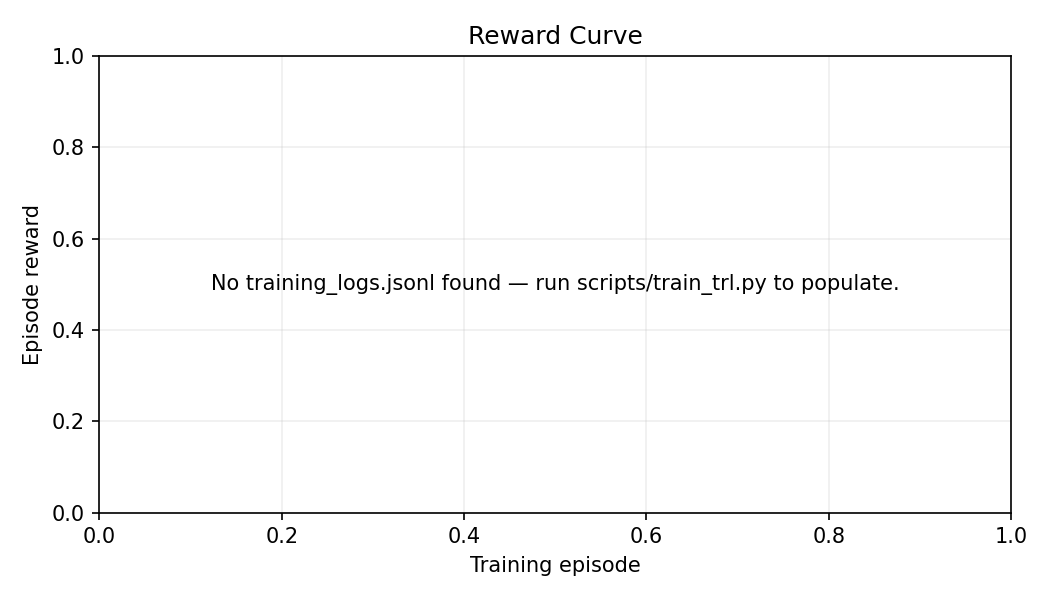

**loss_curve.png** — SFT cross-entropy + RL policy loss.

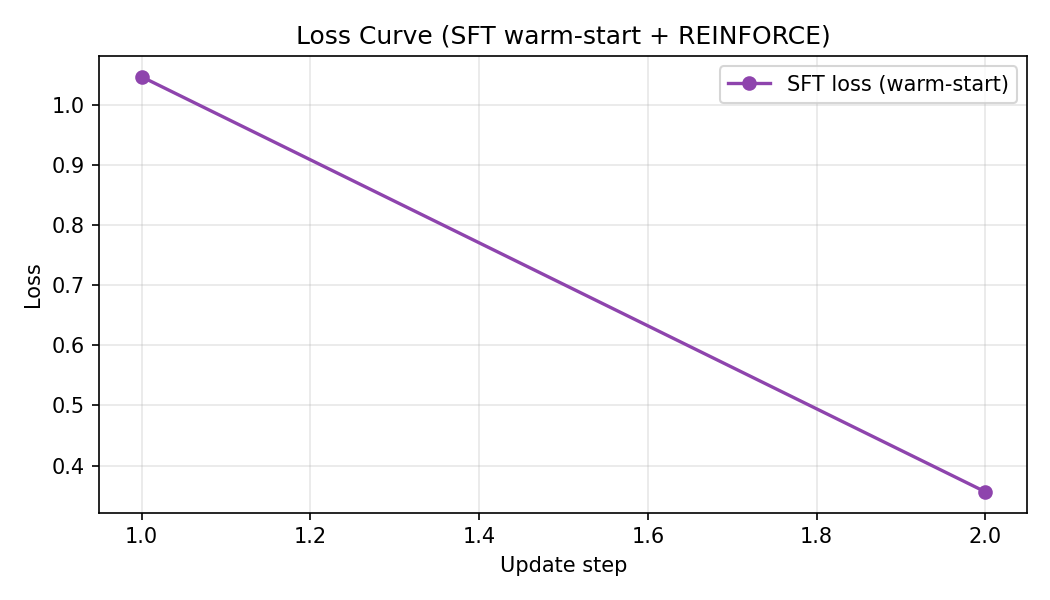

**outage_comparison.png** — Average outages per episode by agent.

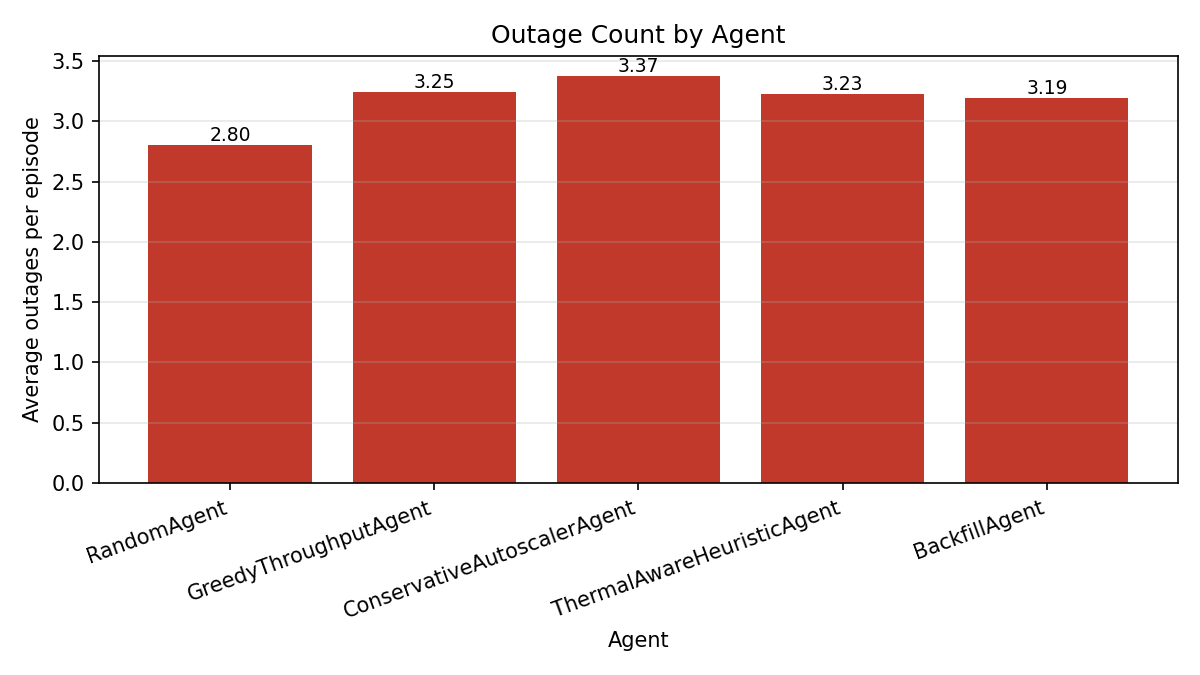

**cascade_count_comparison.png** — Linked-failure cascades per agent.

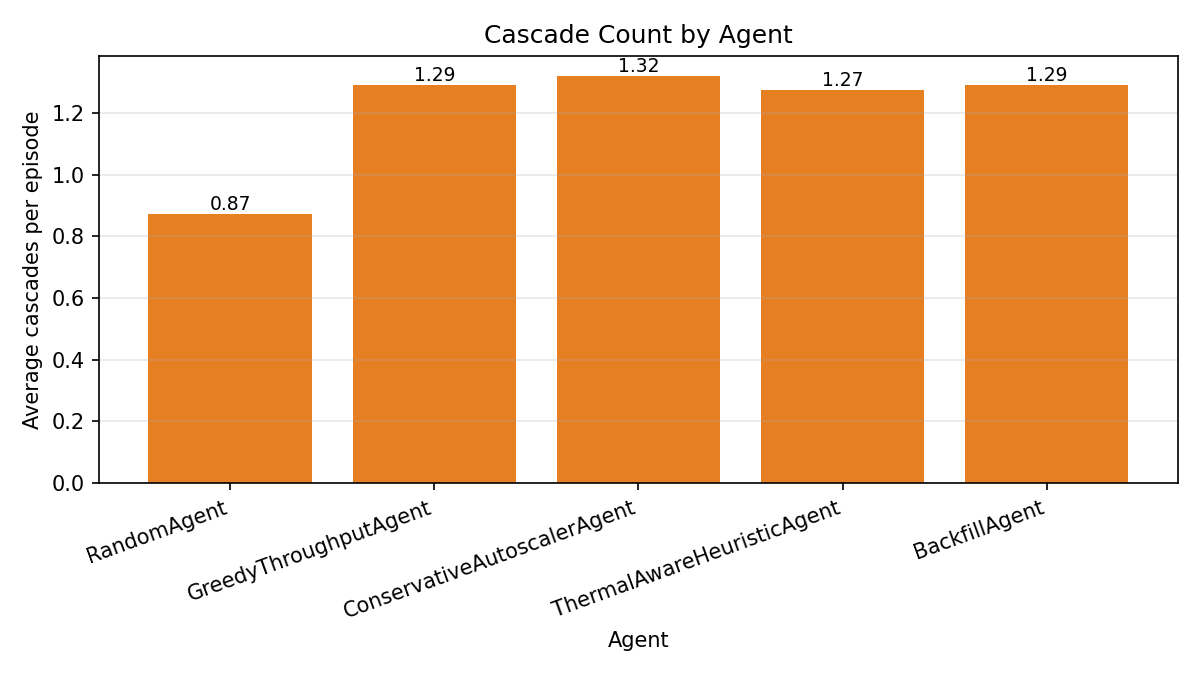

**critical_job_completion.png** — Critical-job completion rate.

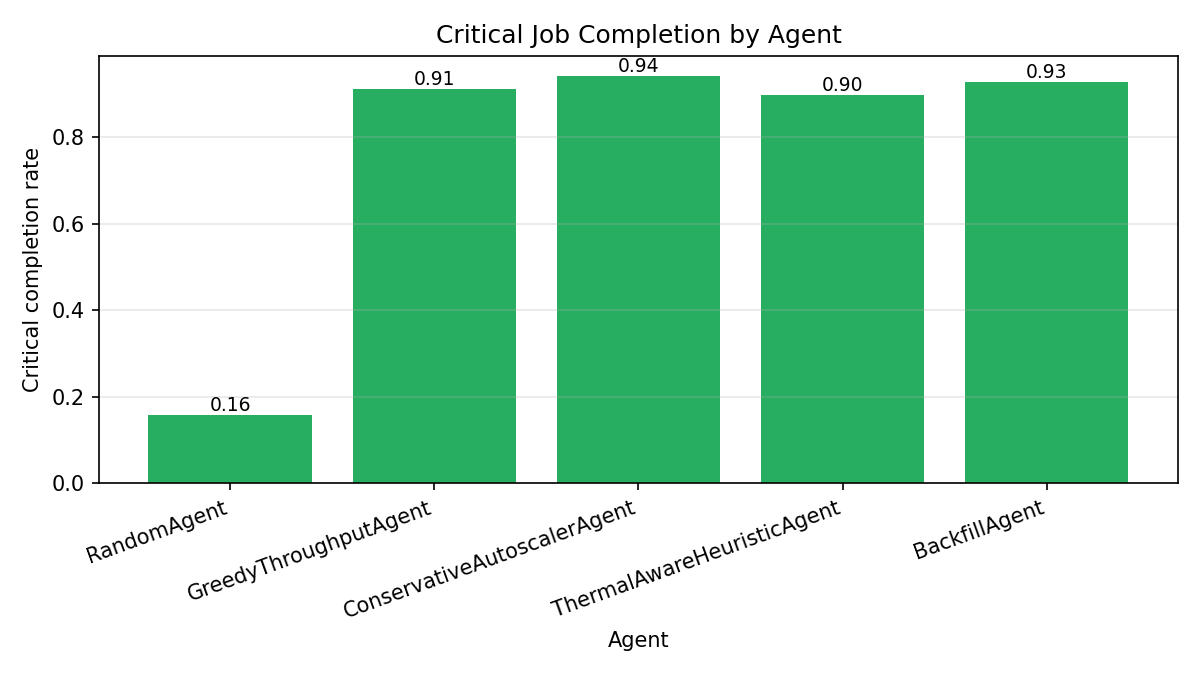

**guardrail_violations.png** — Guardrail-violation rate.

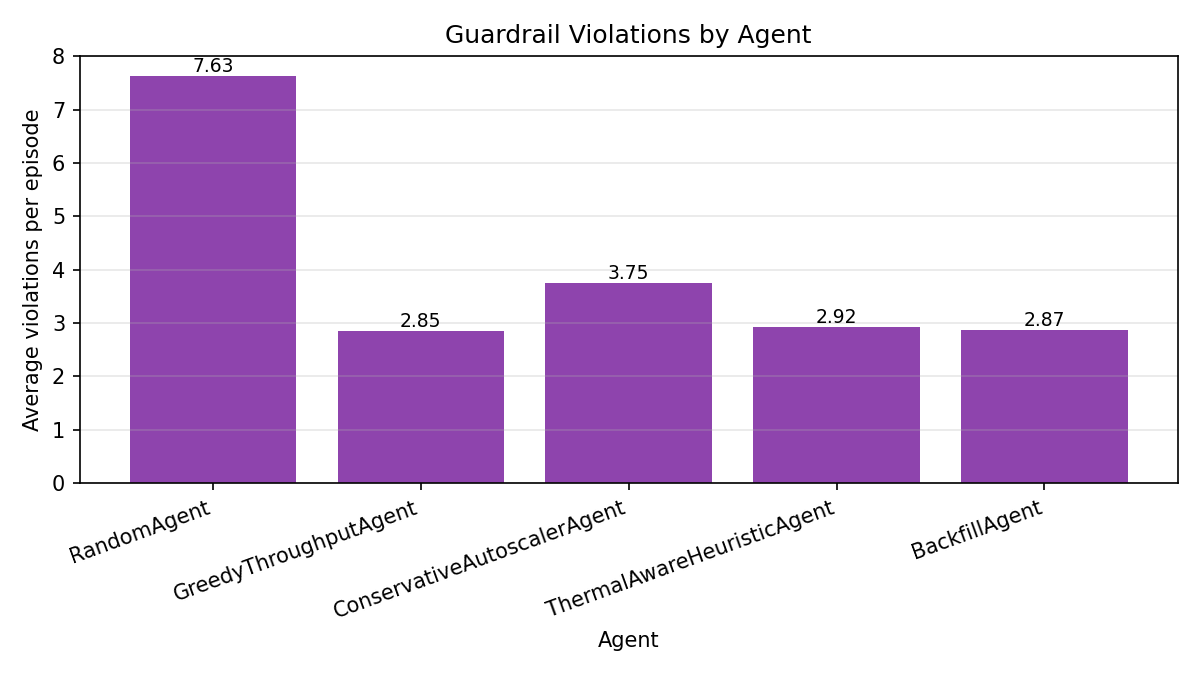

**chaos_survival_score.png** — Chaos-survival proxy (reward x crit completion).

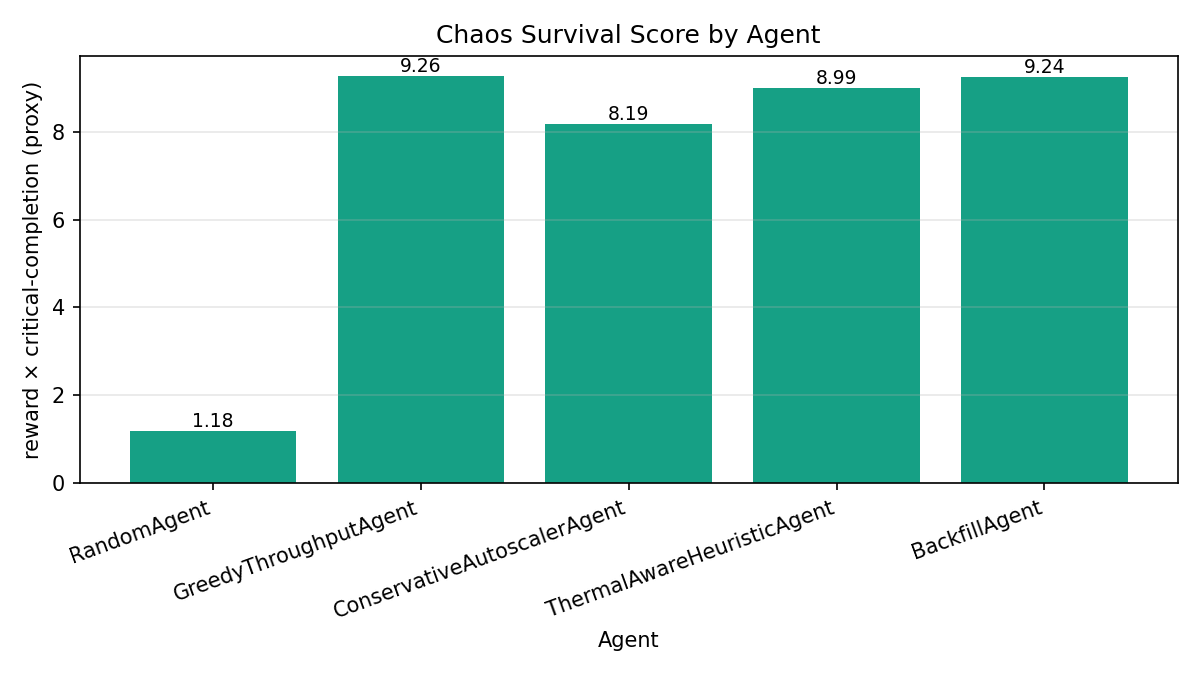

**cluster_health_curve.png** — Cluster health rolling mean during training.

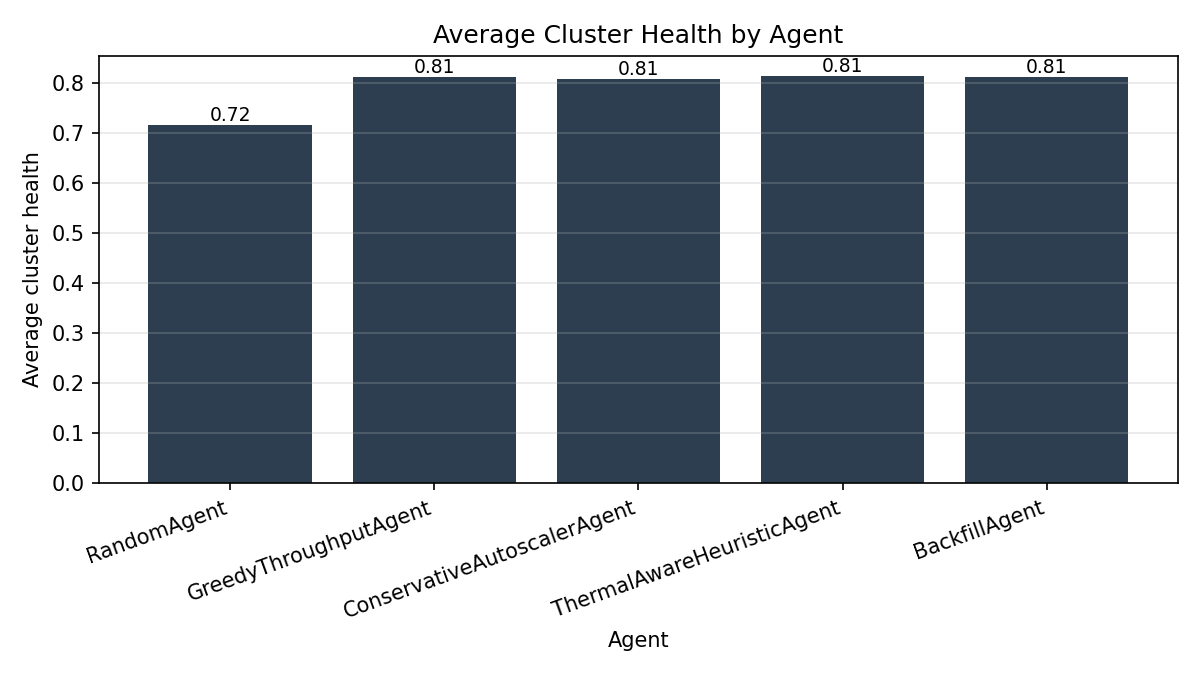

In [13]:
from IPython.display import Image, display, Markdown
captions = {
    'reward_curve.png': 'Per-episode RL reward across live env rollouts.',
    'loss_curve.png': 'SFT cross-entropy + RL policy loss.',
    'outage_comparison.png': 'Average outages per episode by agent.',
    'cascade_count_comparison.png': 'Linked-failure cascades per agent.',
    'critical_job_completion.png': 'Critical-job completion rate.',
    'guardrail_violations.png': 'Guardrail-violation rate.',
    'chaos_survival_score.png': 'Chaos-survival proxy (reward x crit completion).',
    'cluster_health_curve.png': 'Cluster health rolling mean during training.',
}
for name, cap in captions.items():
    display(Markdown(f'**{name}** — {cap}'))
    display(Image(filename=f'results/{name}'))

## 10 — Flight Recorder narrative for the storytelling demo

In [14]:
!python scripts/export_replay.py --agent GreedyThroughputAgent --scenario triple_crisis --level 4 --seed 7

wrote /content/clustermind-chaos-arena/results/replays/GreedyThroughputAgent__triple_crisis__L4__seed7.json
wrote /content/clustermind-chaos-arena/results/replays/GreedyThroughputAgent__triple_crisis__L4__seed7__failure_chain.txt

--- failure chain ---
Step  1: agent=ALLOCATE_JOB  chaos=—  events=allocate:job_1->gpu_2; node_failed:gpu_0; node_failed:gpu_3; node_failed:gpu_9 — failures: gpu_0, gpu_3, gpu_9 | cascade: shock:gpu_0->gpu_4,gpu_1, shock:gpu_3->gpu_2,gpu_4, shock:gpu_9->gpu_8,gpu_5
Step  2: agent=ALLOCATE_JOB  chaos=—  events=allocate:job_4->gpu_7; node_failed:gpu_4 — failures: gpu_4 | cascade: linked:gpu_4@step2
Step  3: agent=ALLOCATE_JOB  chaos=—  events=allocate:job_0->gpu_6
Step  4: agent=ALLOCATE_JOB  chaos=—  events=allocate:job_2->gpu_5


## 11 — Trained-agent demo loop (LoRA path only)

In [15]:
import os
if os.path.isdir('results/adapters/clustermind_lora'):
    from clustermind import ClusterMindChaosEnv
    from clustermind.agents import LLMJsonAgent, TransformersBackend
    from clustermind.baselines import ThermalAwareHeuristicAgent
    backend = TransformersBackend(model_name='Qwen/Qwen2.5-0.5B-Instruct',
                                  adapter_path='results/adapters/clustermind_lora')
    agent = LLMJsonAgent(backend=backend, fallback_baseline=ThermalAwareHeuristicAgent(), label='RL-LoRA')
    env = ClusterMindChaosEnv()
    obs = env.reset(seed=99, options={'scenario': 'chaos_arena', 'curriculum_level': 5, 'max_steps': 18})
    total = 0.0
    while not obs.done:
        action = agent.act(obs)
        obs, r, done, info = env.step(action)
        total += r
        chaos = info.get('chaos_action') or '-'
        print(f"step {obs.step:>2}: {action.action_type.value:18s} chaos={chaos:25s} reward={r:+.3f} health={obs.cluster_health:.2f}")
    print(f"\ntotal reward: {total:.2f}\nparse stats: {agent.stats()}")
else:
    print('Skipping — LoRA adapter not present (Step 7 ran the policy-net path).')

Skipping — LoRA adapter not present (Step 7 ran the policy-net path).


## 12 — Final summary table

In [16]:
import json, os
print('=' * 90)
print('FINAL SUMMARY')
print('=' * 90)
if os.path.isfile('results/trained_results.json'):
    with open('results/trained_results.json') as f: tr = json.load(f)
    print(f"Training schema:   {tr.get('schema')}")
    print(f"RL algo used:      {tr.get('rl_algo')}  ({tr.get('rl_algo_note', '')})")
    print(f"Frozen base:       {tr.get('frozen_base')}")
    print(f"LoRA-only updates: {tr.get('lora_only')}")
    if tr.get('eval_mean_reward') is not None:
        print(f"Trained-agent eval mean reward: {tr['eval_mean_reward']:.2f}")
if os.path.isfile('results/evaluation_metrics.json'):
    with open('results/evaluation_metrics.json') as f: ev = json.load(f)
    print()
    print(f"{'agent':25s} {'reward':>7s} {'crit%':>6s} {'outage':>7s} {'cascade':>8s} {'grade':>6s}")
    for name, blob in ev['agents'].items():
        s = blob['summary']
        band = blob.get('overall_band', '-')
        print(f"{name:25s} {s.get('avg_reward', 0):7.2f} {s.get('critical_completion_rate', 0)*100:5.1f}%"
              f" {s.get('avg_outage_count', 0):7.2f} {s.get('avg_cascade_count', 0):8.2f} {band:>6s}")

FINAL SUMMARY
Training schema:   clustermind.training.policy_net.v1
RL algo used:      reinforce  (policy-net path uses REINFORCE with moving baseline (no LLM stack present))
Frozen base:       False
LoRA-only updates: False
Trained-agent eval mean reward: 12.84

agent                      reward  crit%  outage  cascade  grade
RandomAgent                  7.48  15.8%    2.80     0.87      F
GreedyThroughputAgent       10.16  91.1%    3.25     1.29      C
ConservativeAutoscalerAgent    8.70  94.2%    3.37     1.32      C
ThermalAwareHeuristicAgent   10.02  89.7%    3.23     1.27      C
BackfillAgent                9.94  92.9%    3.19     1.29      C


## Done
Artifacts to commit / upload to the HF Space:
- `results/adapters/clustermind_lora/` — trained LoRA adapter (frozen base, LoRA only)
- `results/training_logs.jsonl` — per-episode reward + loss + algo
- `results/trained_results.json` — final summary with `rl_algo`, `frozen_base`, `lora_only`
- `results/*.png` — the eight required plots
- `results/replays/*.json` — Flight Recorder rollouts

**Honest disclosure:** if Step 7 ran the policy-net plumbing path (no transformers/peft), the schema in `trained_results.json` will be `clustermind.training.policy_net.v1` — that proves the pipeline runs but is *not* an LLM/LoRA result. To get LLM/LoRA evidence, run this notebook on Colab where transformers + peft are installed.